In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import contextily
import pygmt
from pygmt.params import Axis
from pygmt.params import Box, Frame, Position

from obspy.core import UTCDateTime
from obspy.clients import fdsn
from obspy import Catalog

class LoadError(BaseException):
    pass
    
def ep2c(ep):
    lons = []
    lats = []
    for e in ep:
        o = e.preferred_origin()
        lons.append(o.longitude)
        lats.append(o.latitude)
    return { 'x':np.array(lons), 'y':np.array(lats)}

def mda2c(mda):
    lats = np.array([ S.latitude for S in mda])
    lons = np.array([ S.longitude for S in mda])
    names = np.array([ S.code for S in mda])
    return { 'x':lons, 'y': lats, 'text' : names}

def plot_box(fig, region, pen):

    minlon, maxlon, minlat, maxlat = region

    x = [minlon,maxlon,maxlon,minlon,minlon]

    y = [minlat,minlat,maxlat,maxlat,minlat]

    fig.plot(x=x, y=y, pen=pen)

In [2]:
# Metadata

from obspy.clients import fdsn

cl = fdsn.Client("http://10.110.0.134") # seisarc.sismo.iag.usp.br

vlon = cl.get_stations(net="VL", endafter=UTCDateTime.now())
vlon = [ S for N in vlon.networks for S in N.stations ]

vloff = cl.get_stations(net="VL", endbefore=UTCDateTime.now())
vloff = [ S for N in vloff.networks for S in N.stations ]

rsbr = cl.get_stations(net="BL,BR,ON,NB", endafter=UTCDateTime.now())
rsbr = [ S for N in rsbr.networks for S in N.stations ]

print(f"RSVL ativas      = {len(vlon)}")
print(f"RSVL desativadas = {len(vloff)}")
print(f"RSBR ativas      = {len(rsbr)}")

RSVL ativas      = 11
RSVL desativadas = 7
RSBR ativas      = 100


In [3]:
def region_map(minlon,maxlon,minlat,maxlat, num_evs, leg='a)', zoom=5, stations=True, alpha=0, grid=True):
    if num_evs != 0:
        ep = cl.get_events(limit = num_evs, minlatitude=minlat, maxlatitude=maxlat, minlongitude=minlon, maxlongitude=maxlon)

    fig = pygmt.Figure()
    
    pygmt.config(MAP_FRAME_TYPE="plain")
    pygmt.config(FORMAT_GEO_MAP="ddd.xx")
    
    fig.tilemap(
        region=[minlon,maxlon,minlat,maxlat],
        projection="M11c",
        # Set level of details (0-22)
        # Higher levels mean a zoom level closer to the Earth's
        # surface with more tiles covering a smaller
        # geographic area and thus more details and vice versa
        # Please note, not all zoom levels are always available
        zoom=zoom,
        # Use tiles from OpenStreetMap tile server
        source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png", #"https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
        frame=Axis(annot=True, tick=True, grid=grid),
    )

    ## ESCALE
    # fig.scalebar(
    #             length="10k",
    #             position=("7.6c", "0.6c"),
    #             fancy=True,
    #             height=None,
    #             box=False
    #             )
    # Londrina position scalebar: ("9.7c", "1.8c")
    # Frutal "": ("7.6c", "0.6c") | grid=0.15
    
    if num_evs != 0:
        fig.plot(ep2c(ep),
                 style = "a0.2",
                 pen  = '.4p,black',
                 fill  = "gold3",
                 transparency = 30, label = 'Events')
    
    fig.text(text=leg,position="TL",fill="white", offset=(0.2,-0.2), font="14p,Helvetica-Bold,black")

    if stations:
        # fig.plot(mda2c(vloff), style="t0.5", pen="0.5p,white", fill="gray", label = "Deactivated (VL)")
        # fig.plot(mda2c(vlon),  style="t0.5", pen="0.5p,white", fill="black", label = "Station (VL)")
        fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (RSBR)", transparency=alpha)
    
    fig.legend(position="BR",
               line_spacing = 1.5,
               box = Box(pen="1p,black", fill="white@30"))
    print()
    fig.show()

legend [WARNING]: File <stdin> is empty!


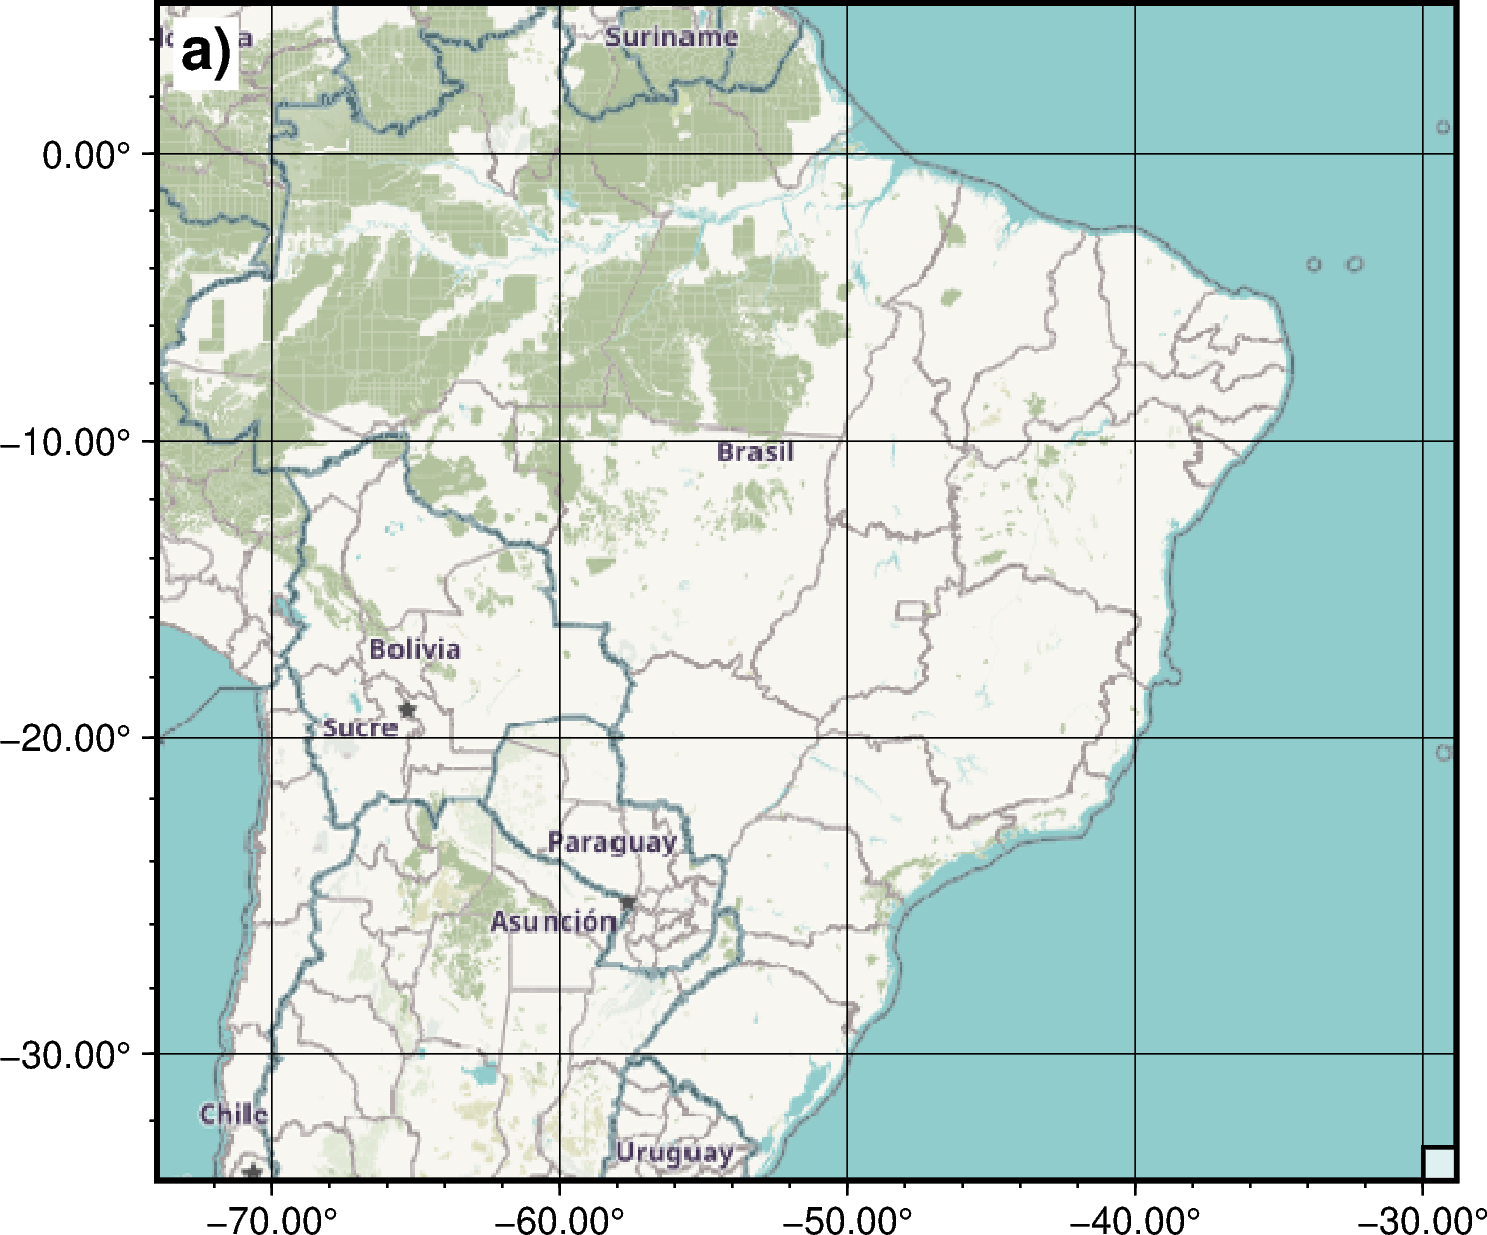

In [4]:
# Mapa Brasil
region_map(-73.99, -28.84, -33.75, 5.27, num_evs=0, zoom=4, stations=False, alpha=30)

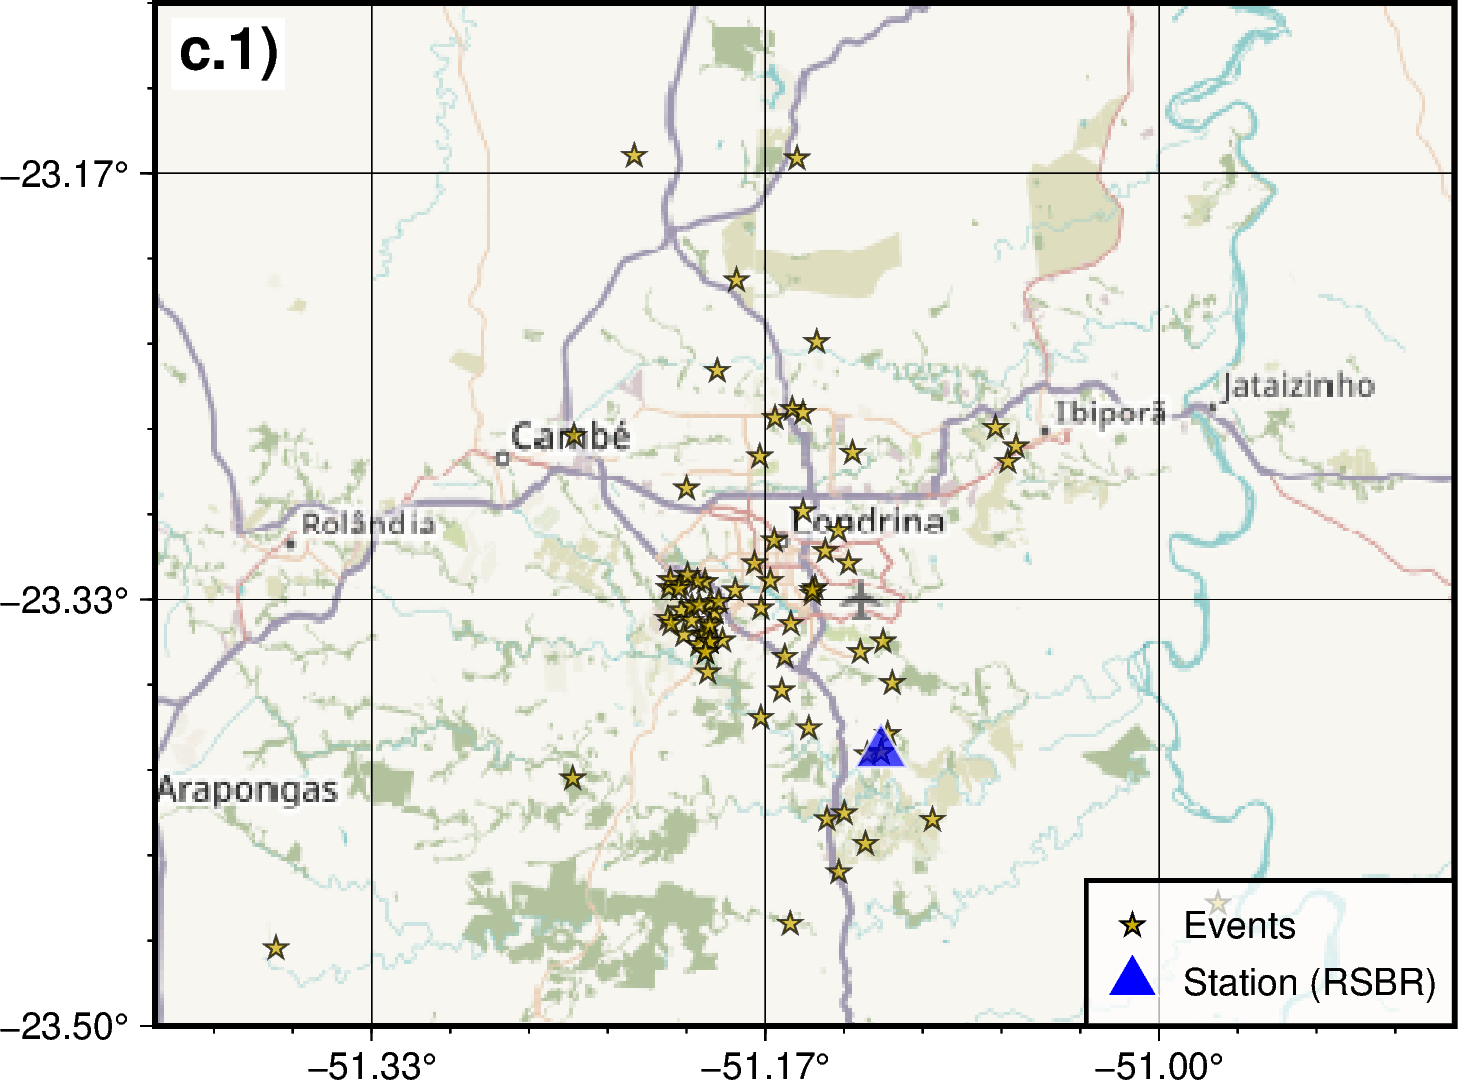

In [5]:
# Mapa Londrina/PR

region_map(-51.425, -50.875, -23.5, -23.1, num_evs=100, zoom=10, stations=True, alpha=30, leg='c.1)')

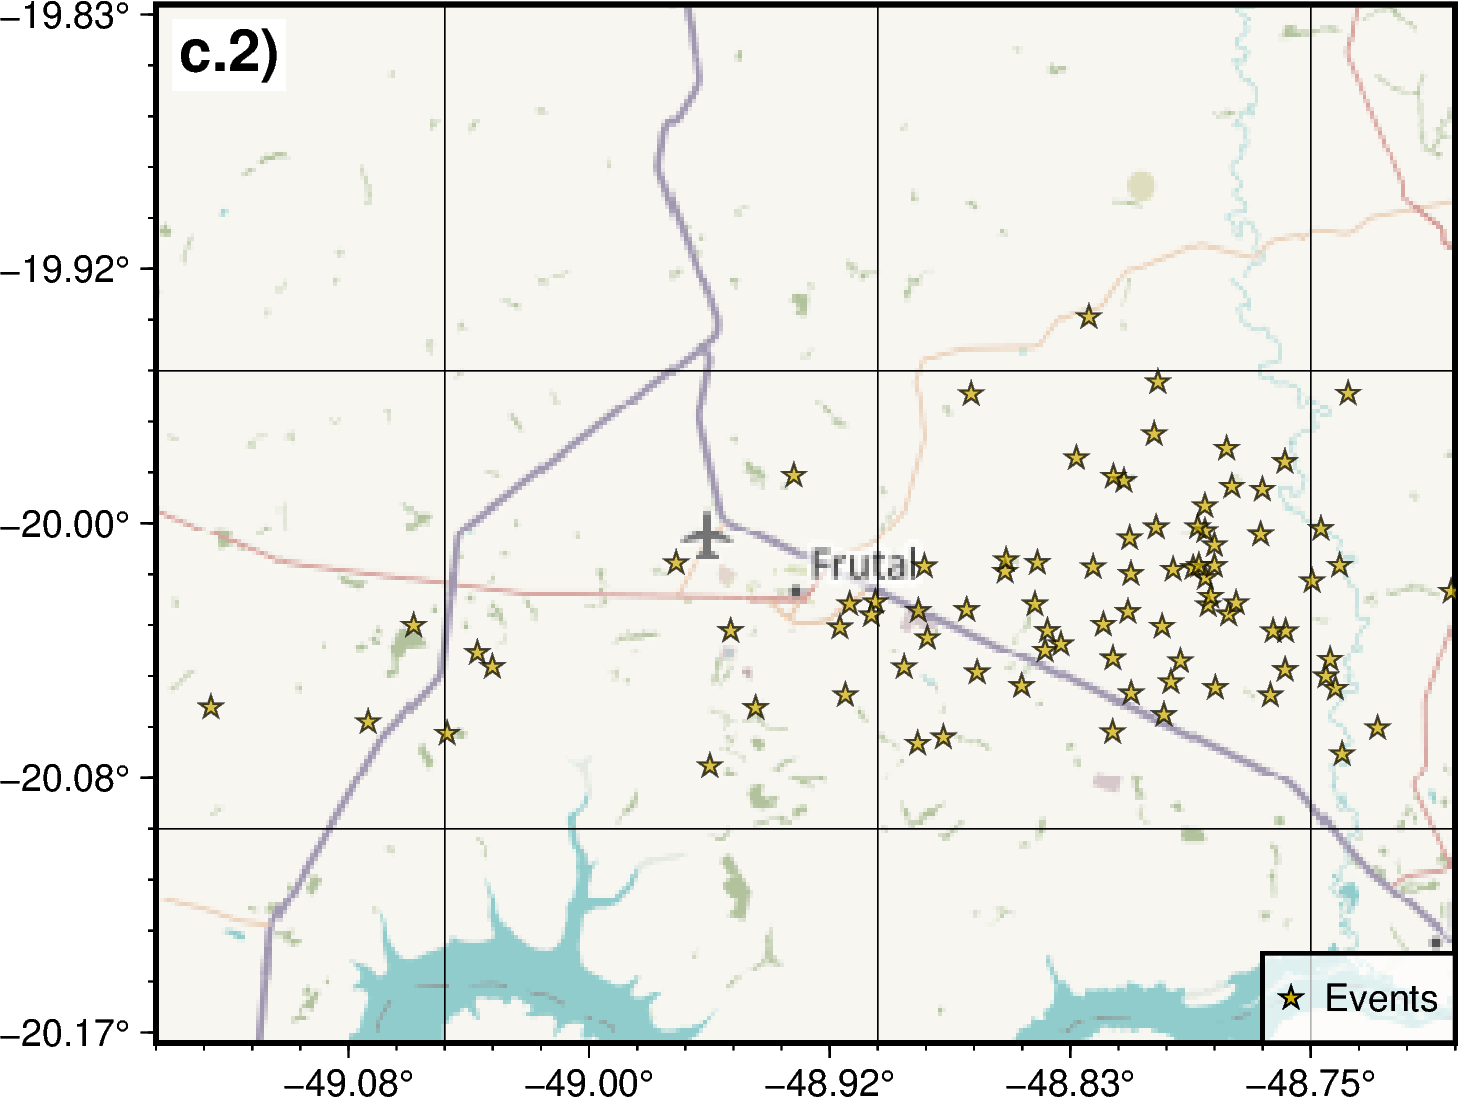

In [6]:
# Mapa Frutal/MG
region_map(-49.15, -48.70, -20.17, -19.83, num_evs=100, zoom=10, stations=False, alpha=30, leg='c.2)', grid=0.15)

In [7]:
# Region
#minlon=-53.0, maxlon=-49.2, minlat=-24.7, maxlat=-22.0, --> Londrina
#minlon=-50.6, maxlon=-47.1, minlat=-21.2, maxlat=-18.4, --> Frutal
minlon = -51.7
maxlon = -50.6

minlat = -23.7
maxlat = -22.9

# Last 100 events in brazil
ep = cl.get_events(limit = 100, minlatitude=minlat, maxlatitude=maxlat, minlongitude=minlon, maxlongitude=maxlon)


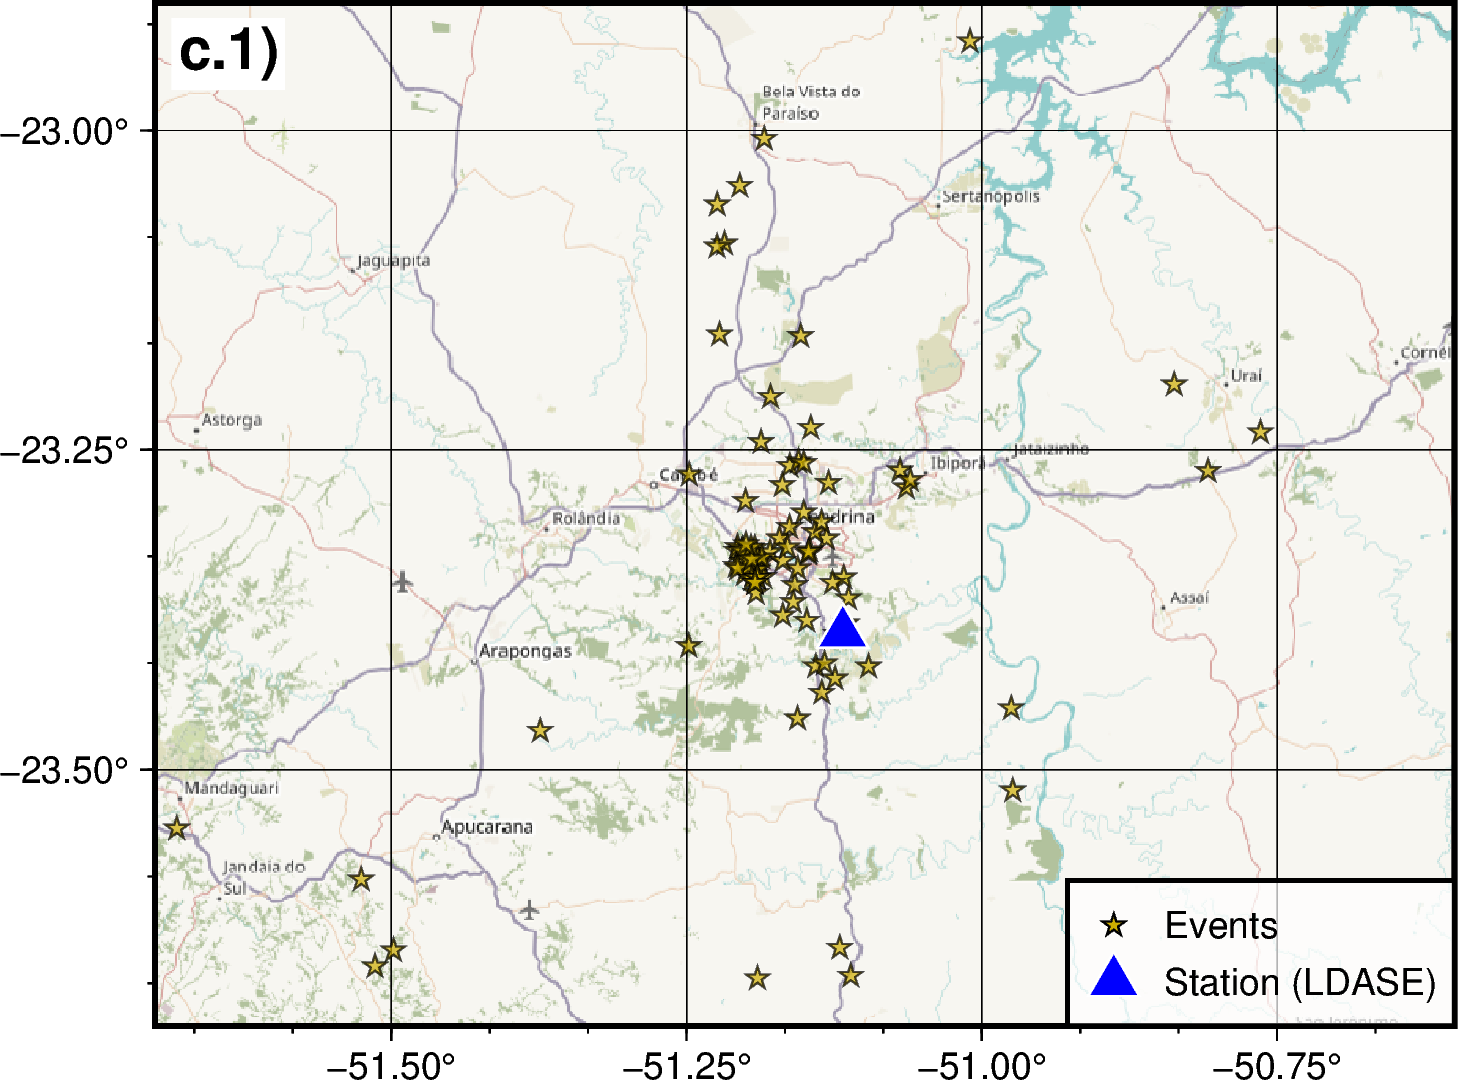

In [8]:
fig = pygmt.Figure()

pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig.tilemap(
    region=[minlon,maxlon,minlat,maxlat],
    projection="M11c",
    # Set level of details (0-22)
    # Higher levels mean a zoom level closer to the Earth's
    # surface with more tiles covering a smaller
    # geographic area and thus more details and vice versa
    # Please note, not all zoom levels are always available
    zoom=10,
    # Use tiles from OpenStreetMap tile server
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=Axis(annot=True, tick=True, grid=True),
)

fig.plot(ep2c(ep),
         style = "a0.2",
         pen  = '.4p,black',
         fill  = "gold3",
         transparency = 30, label = 'Events')

fig.text(text="c.1)",position="TL",fill="white", offset=(0.2,-0.2), font="14p,Helvetica-Bold,black")

# fig.plot(mda2c(vloff), style="t0.5", pen="0.5p,white", fill="gray", label = "Deactivated (VL)")
# fig.plot(mda2c(vlon),  style="t0.5", pen="0.5p,white", fill="black", label = "Station (VL)")
fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (LDASE)")

fig.legend(position="BR",
           line_spacing = 1.5,
           box = Box(pen="1p,black", fill="white@30"))

fig.show()

In [9]:
# Londrina
londrina_region = [-51.425, -50.875, -23.5, -23.1]

# Frutal
frutal_region = [-49.15, -48.70, -20.17, -19.83]

# Região abrangendo as duas áreas
regional_region = [
    -55.0, -44.0,
    -27.0, -17.0
]

# Brasil
brazil_region = [
    -74.0, -34.0,
    -34.0, 6.0
]

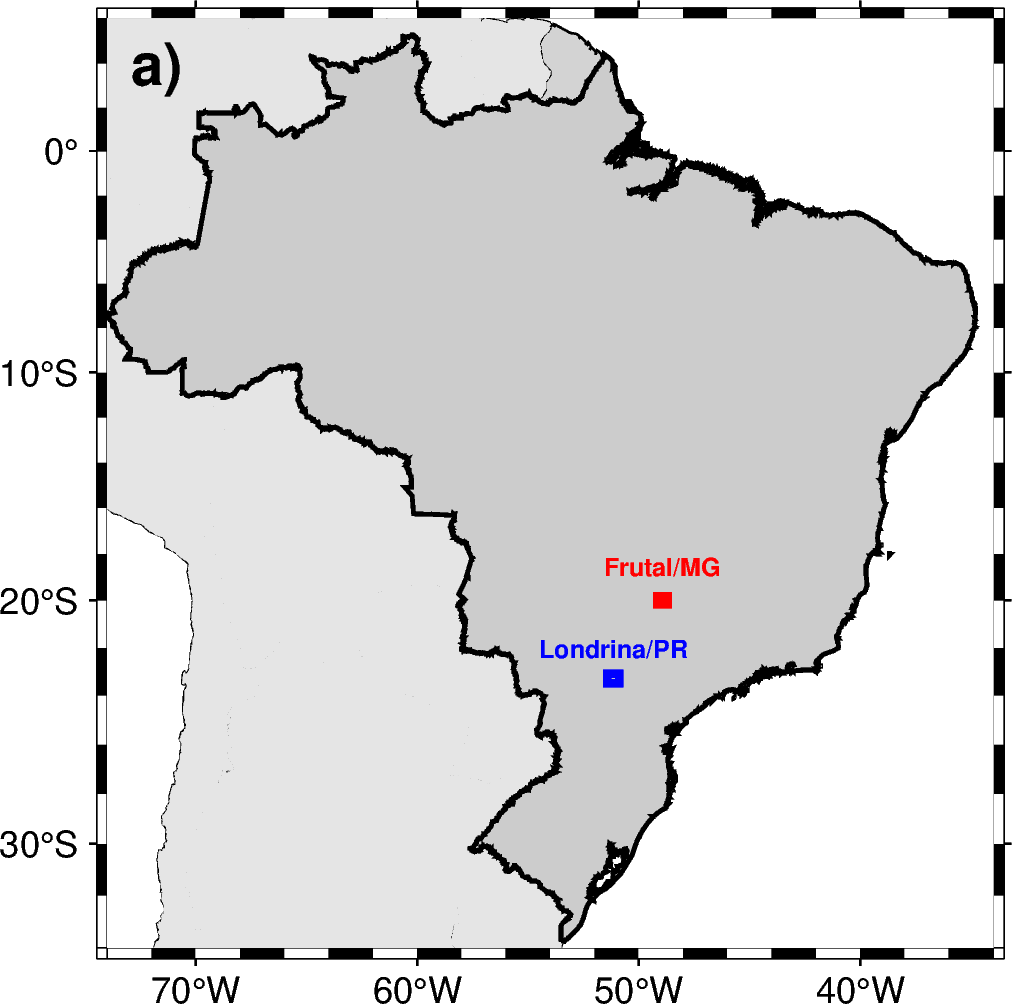

In [10]:
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig = pygmt.Figure()

fig.basemap(region=brazil_region, projection="M7.5c", frame=True)

# Mapa base
fig.coast(
        resolution="l",
        shorelines="0.5p,black",
        borders="1/0.5p,black",
        land="lightgray",
        water="white"
        )

#  Pinta os países da América do Sul
fig.coast(dcw=[
            "AR+ggray90",
            "BO+ggray90",
            "CL+ggray90",
            "CO+ggray90",
            "EC+ggray90",
            "GY+ggray90",
            "PE+ggray90",
            "PY+ggray90",
            "SR+ggray90",
            "UY+ggray90",
            "VE+ggray90",
            "FK+ggray90"
            ]
            )

# Destaca o Brasil
fig.coast(
        region=brazil_region,
        dcw="BR+ggray80+p1p,black"
        )


fig.text(text="a)", position="TL", fill="white@100", offset=(0.2,-0.2), font="14p,Helvetica-Bold,black")

# Caixa Londrina
plot_box(fig, londrina_region, pen="2p,blue")
# Nome de Londrina
fig.text(
    x=-51.15,
    y=-22.05,
    text="Londrina/PR",
    font="6p,Helvetica-Bold,blue",
    justify="CM"
    )

# Caixa Frutal
plot_box(fig, frutal_region, pen="2p,red")
# Nome de Frutal
fig.text(
    x=-48.95,
    y=-18.55,
    text="Frutal/MG",
    font="6p,Helvetica-Bold,red",
    justify="CM"
    )

fig.show()

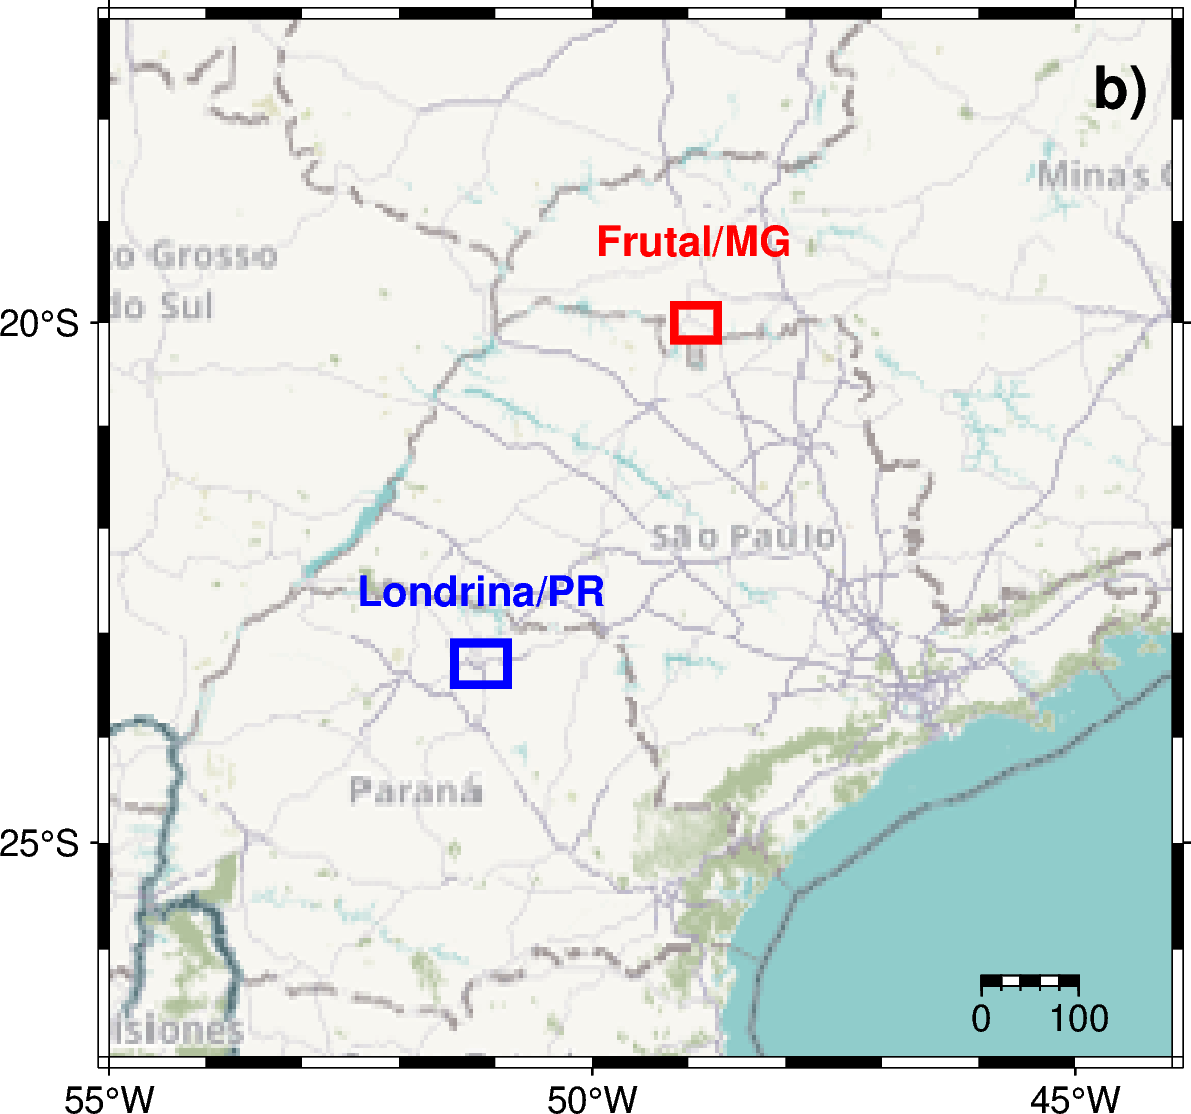

In [11]:
# ============================================================
# B) MAPA REGIONAL
# ============================================================

fig = pygmt.Figure()

fig.shift_origin(
    xshift="8.5c"
)

fig.tilemap(
    region=regional_region,
    projection="M9c",
    zoom=5,
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=True
)


# Escala gráfica
fig.scalebar(
    length="100k",
    position=("7.8c", "0.6c"),
    fancy=True,
    height=None,
    box=False
)

# Letra do painel
fig.text(
    text="b)",
    position="TR",
    fill="white@100",
    offset=(-0.2, -0.4),
    font="14p,Helvetica-Bold,black"
)

# Caixa de Londrina
plot_box(
    fig,
    londrina_region,
    pen="2p,blue"
)

fig.text(
    x=-51.15,
    y=-22.75,
    text="Londrina/PR",
    font="10p,Helvetica-Bold,blue",
    justify="CB"
)

# Caixa de Frutal
plot_box(
    fig,
    frutal_region,
    pen="2p,red"
)

fig.text(
    x=-48.95,
    y=-19.35,
    text="Frutal/MG",
    font="10p,Helvetica-Bold,red",
    justify="CB"
)

fig.show()

In [12]:
# Find event
def get_time(event, phase):
    FDSN = fdsn.Client('http://10.110.0.134')
    try:
        evp = FDSN.get_events(eventid = event, includearrivals = True)
    
    except Exception as e:
        raise LoadError(f"W:> Event {event} not found on FDSN server")
    
    E = evp[0]
    O = E.preferred_origin()

    # Find Arrival & Pick
    for A in O.arrivals:
        if A.time_weight <= 0.0: continue
        if A.phase != phase: continue
        P = [ P for P in E.picks if P.resource_id == A.pick_id ][0]

        return P.time

In [13]:
# Mapa de Londrina SÓ com os sismos selecionados

ids = """
usp2026cnlf usp2026bkpk usp2026bitf usp2026bfhg usp2026arqi usp2026aqoy usp2026aqny usp2026anvt usp2026alkz usp2026ahov usp2026ahfx usp2026agbq usp2026afyv usp2026afxw usp2026aekk usp2026abut usp2025zohl usp2025znlc usp2025zmtj usp2025zgxm usp2025zgno usp2025zgng usp2025zgnd usp2025zgjg usp2025zgiy usp2025zgau usp2024qgjq usp2020nkhq usp2019hlbl usp2019dmvk usp2018tliv usp2018dbml usp2018dbep usp2018cxej usp2018cdft usp2018bojv usp2018boet usp2018blwx usp2016cink usp2016blue usp2016bhtr usp2016bhsg usp2016bhqu usp2016avbr usp2016atoc usp2016atho usp2016asmh
""".split()

ep = Catalog()
for event_id in ids:
    ep += cl.get_events(eventid=event_id)
    
minlon = -51.255
maxlon = -51.05

minlat = -23.40
maxlat = -23.228

# TODOS os IDs
# usp2026cnlf usp2026bkpk usp2026bitf usp2026bfhg usp2026arqi usp2026aqoy usp2026aqny usp2026anvt usp2026alkz usp2026ahov usp2026ahfx usp2026agbq usp2026afyv usp2026afxw usp2026aekk usp2026abut usp2025zohl usp2025znlc usp2025zmtj usp2025zgxm usp2025zgno usp2025zgng usp2025zgnd usp2025zgjg usp2025zgiy usp2025zgau usp2024qgjq usp2020nkhq usp2019hlbl usp2019dmvk usp2018tliv usp2018dbml usp2018dbep usp2018cxej usp2018cdft usp2018bojv usp2018boet usp2018blwx usp2016cink usp2016blue usp2016bhtr usp2016bhsg usp2016bhqu usp2016avbr usp2016atoc usp2016atho usp2016asmh

# IDs BEM correlacionados
# usp2016atho usp2016atoc usp2016avbr usp2016bhqu usp2018blwx usp2018boet usp2018bojv usp2018cdft usp2018cxej usp2018dbep usp2018dbml usp2024qgjq usp2025zgiy usp2025zgnd usp2025zgng usp2026abut usp2026aekk usp2026agbq usp2026ahfx usp2026ahov usp2026alkz usp2026anvt usp2026aqoy usp2026arqi usp2026bfhg usp2026bitf usp2026bkpk usp2026cnlf

# IDs MAL correlacionados
# usp2016asmh usp2016bhsg usp2016bhtr usp2016blue usp2016cink usp2018tliv usp2019dmvk usp2019hlbl usp2020nkhq usp2025zgau usp2025zgjg usp2025zgno usp2025zgxm usp2025zmtj usp2025znlc usp2025zohl usp2026afxw usp2026afyv usp2026aqny

Num events: 47



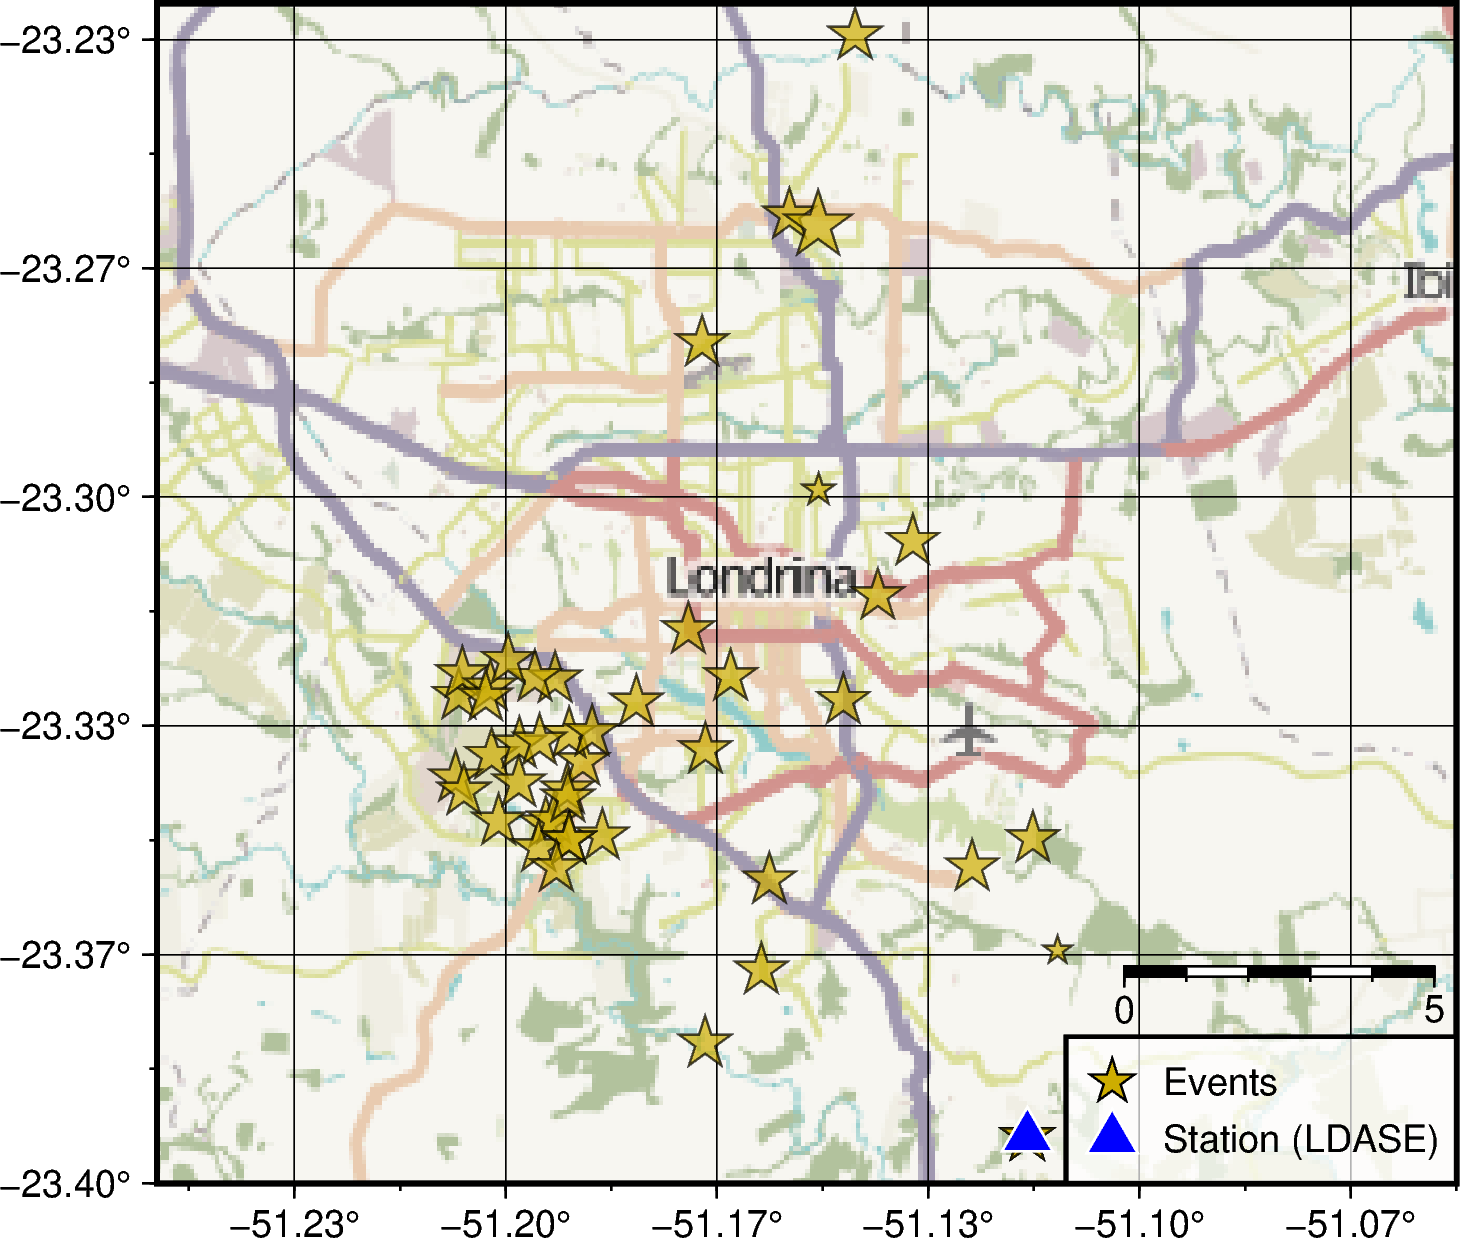

In [18]:
# TODOS
ids = """
usp2026cnlf usp2026bkpk usp2026bitf usp2026bfhg usp2026arqi usp2026aqoy usp2026aqny usp2026anvt usp2026alkz usp2026ahov usp2026ahfx usp2026agbq usp2026afyv usp2026afxw usp2026aekk usp2026abut usp2025zohl usp2025znlc usp2025zmtj usp2025zgxm usp2025zgno usp2025zgng usp2025zgnd usp2025zgjg usp2025zgiy usp2025zgau usp2024qgjq usp2020nkhq usp2019hlbl usp2019dmvk usp2018tliv usp2018dbml usp2018dbep usp2018cxej usp2018cdft usp2018bojv usp2018boet usp2018blwx usp2016cink usp2016blue usp2016bhtr usp2016bhsg usp2016bhqu usp2016avbr usp2016atoc usp2016atho usp2016asmh
""".split()

ep = Catalog()
for event_id in ids:
    ep += cl.get_events(eventid=event_id)

diff = []
for evid in ep:
    event_id = str(evid.resource_id)
    P = get_time(event_id[-11:], 'P')
    S = get_time(event_id[-11:], 'S')
    diff.append(S - P)
# Normaliza S-P entre 0 e 1
diff = np.array(diff)
diff = [(item - diff.min()) / (diff.max() - diff.min()) for item in diff]

# Define o tamanho das estrelas mínimo = 0.15 cm máximo = 0.8 cm
star_size = [0.25 + 0.35 * np.sqrt(x) for x in diff]
coords = ep2c(ep)


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig.tilemap(
    region=[minlon,maxlon,minlat,maxlat],
    projection="M11c",
    zoom=11,
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=Axis(annot=True, tick=True, grid=True),
)

# fig.plot(ep2c(ep),
#          style = "a0.2",
#          pen  = '.4p,black',
#          fill  = "gold3",
#          transparency = 30, label = 'Events')
fig.plot(x=coords["x"],
         y=coords["y"],
         style="a",
         size=star_size,
         pen=".4p,black",
         fill="gold3",
         transparency=30,
        )
fig.plot(
    x=[np.nan],
    y=[np.nan],
    style="a0.4c",
    pen=".4p,black",
    fill="gold3",
    label="Events",
    )

fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (LDASE)")

fig.legend(position="BR",
           line_spacing = 1.5,
           box = Box(pen="1p,black", fill="white@30"))

fig.scalebar(
    length="5k",
    position=("9.5c", "1.75c"),
    fancy=True,
    height=None,
    box=False
)

print(f"Num events: {len(ep)}\n")
fig.show()

Num events: 47



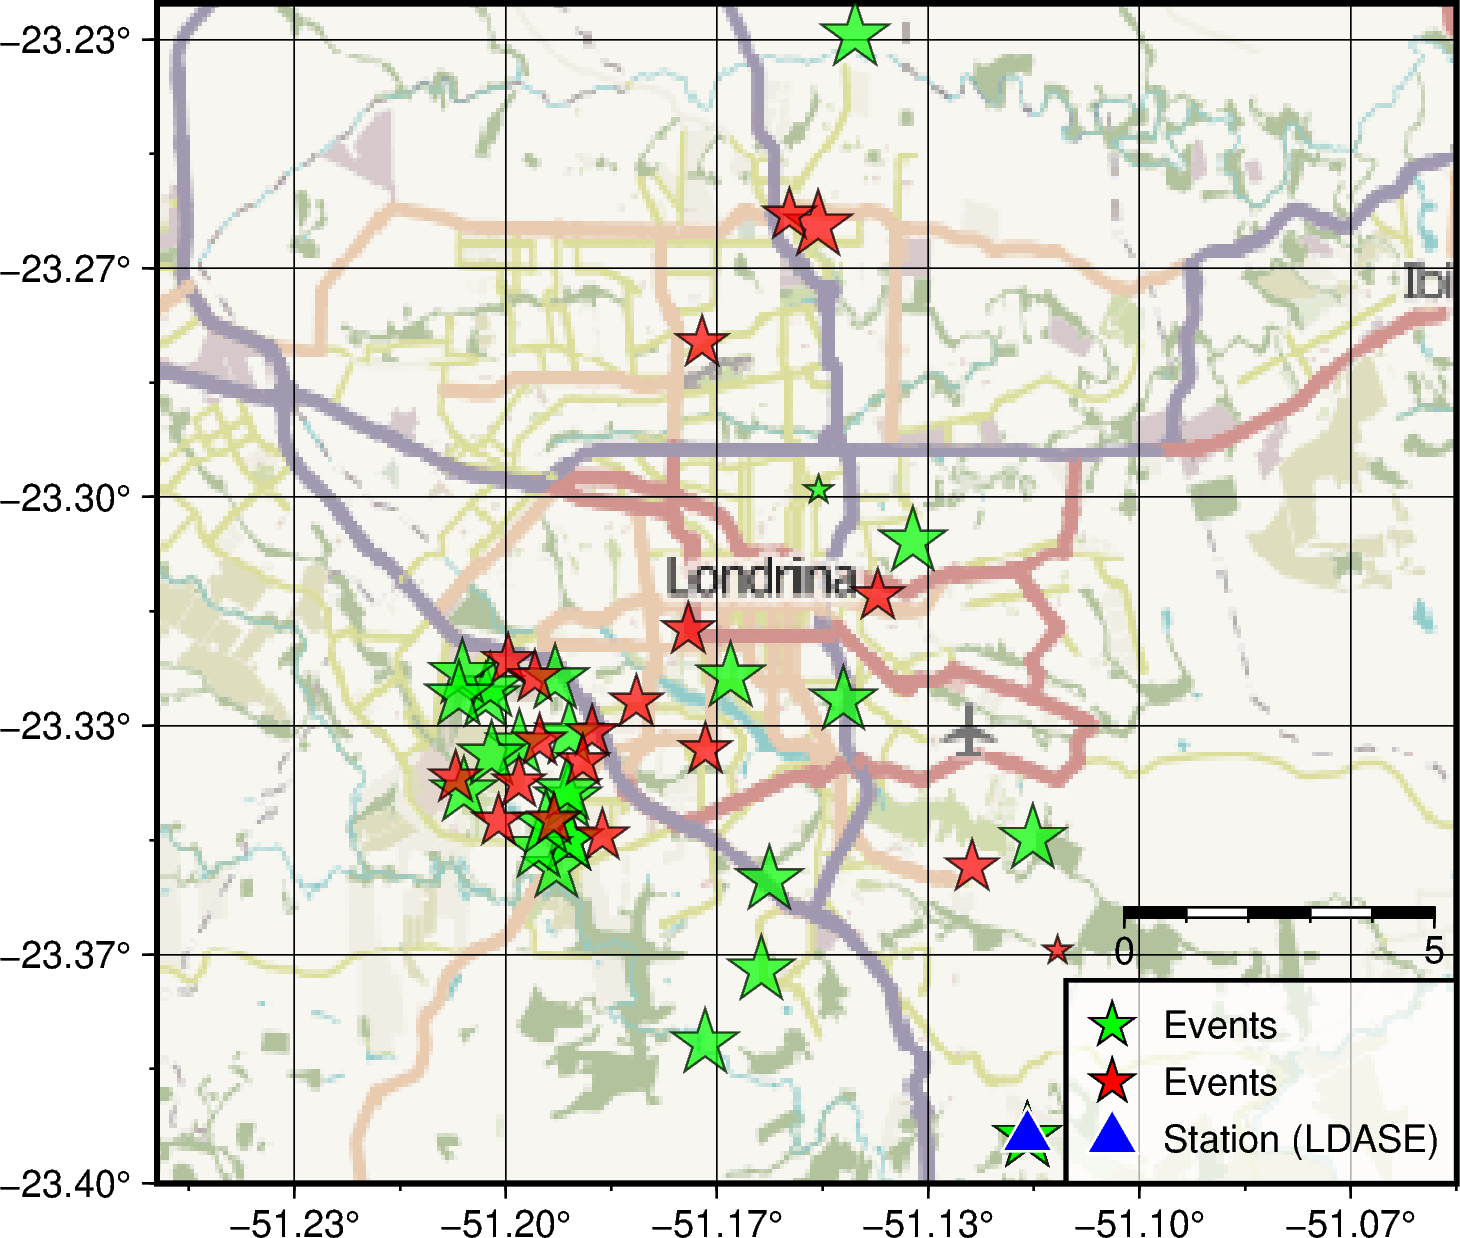

In [19]:
# TODOS (COLORIDO)
ids_BEM = """
usp2016atho usp2016atoc usp2016avbr usp2016bhqu usp2018blwx usp2018boet usp2018bojv usp2018cdft usp2018cxej usp2018dbep usp2018dbml usp2024qgjq usp2025zgiy usp2025zgnd usp2025zgng usp2026abut usp2026aekk usp2026agbq usp2026ahfx usp2026ahov usp2026alkz usp2026anvt usp2026aqoy usp2026arqi usp2026bfhg usp2026bitf usp2026bkpk usp2026cnlf
""".split()
ep1 = Catalog()
for event_id in ids_BEM:
    ep1 += cl.get_events(eventid=event_id)

diff1 = []
for evid in ep1:
    event_id = str(evid.resource_id)
    P = get_time(event_id[-11:], 'P')
    S = get_time(event_id[-11:], 'S')
    diff1.append(S - P)
# Normaliza S-P entre 0 e 1
diff1 = np.array(diff1)
diff1 = [(item - diff1.min()) / (diff1.max() - diff1.min()) for item in diff1]

# Define o tamanho das estrelas mínimo = 0.15 cm máximo = 0.8 cm
star_size1 = [0.25 + 0.35 * np.sqrt(x) for x in diff1]
coords1 = ep2c(ep1)

ids_MAL = """
usp2016asmh usp2016bhsg usp2016bhtr usp2016blue usp2016cink usp2018tliv usp2019dmvk usp2019hlbl usp2020nkhq usp2025zgau usp2025zgjg usp2025zgno usp2025zgxm usp2025zmtj usp2025znlc usp2025zohl usp2026afxw usp2026afyv usp2026aqny
""".split()
ep2 = Catalog()
for event_id in ids_MAL:
    ep2 += cl.get_events(eventid=event_id)

diff2 = []
for evid in ep2:
    event_id = str(evid.resource_id)
    P = get_time(event_id[-11:], 'P')
    S = get_time(event_id[-11:], 'S')
    diff2.append(S - P)
# Normaliza S-P entre 0 e 1
diff2 = np.array(diff2)
diff2 = [(item - diff2.min()) / (diff2.max() - diff2.min()) for item in diff2]

# Define o tamanho das estrelas mínimo = 0.15 cm máximo = 0.8 cm
star_size2 = [0.25 + 0.35 * np.sqrt(x) for x in diff2]
coords2 = ep2c(ep2)


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig.tilemap(
    region=[minlon,maxlon,minlat,maxlat],
    projection="M11c",
    zoom=11,
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=Axis(annot=True, tick=True, grid=True),
)

# fig.plot(ep2c(ep1),
#          style = "a0.2",
#          pen  = '.4p,black',
#          fill  = "GREEN",
#          transparency = 30, label = 'Well corr events')
fig.plot(x=coords1["x"],
         y=coords1["y"],
         style="a",
         size=star_size1,
         pen=".4p,black",
         fill="GREEN",
         transparency=30,
        )
fig.plot(
    x=[np.nan],
    y=[np.nan],
    style="a0.4c",
    pen=".4p,black",
    fill="GREEN",
    label="Events",
    )

# fig.plot(ep2c(ep2),
#          style = "a0.2",
#          pen  = '.4p,black',
#          fill  = "RED",
#          transparency = 30, label = 'Bad  corr events')
fig.plot(x=coords2["x"],
         y=coords2["y"],
         style="a",
         size=star_size2,
         pen=".4p,black",
         fill="RED",
         transparency=30,
        )
fig.plot(
    x=[np.nan],
    y=[np.nan],
    style="a0.4c",
    pen=".4p,black",
    fill="RED",
    label="Events",
    )

fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (LDASE)")

fig.legend(position="BR",
           line_spacing = 1.5,
           box = Box(pen="1p,black", fill="white@30"))

fig.scalebar(
    length="5k",
    position=("9.5c", "2.25c"),
    fancy=True,
    height=None,
    box=False
)

print(f"Num events: {len(ep)}\n")
fig.show()

Num events: 28



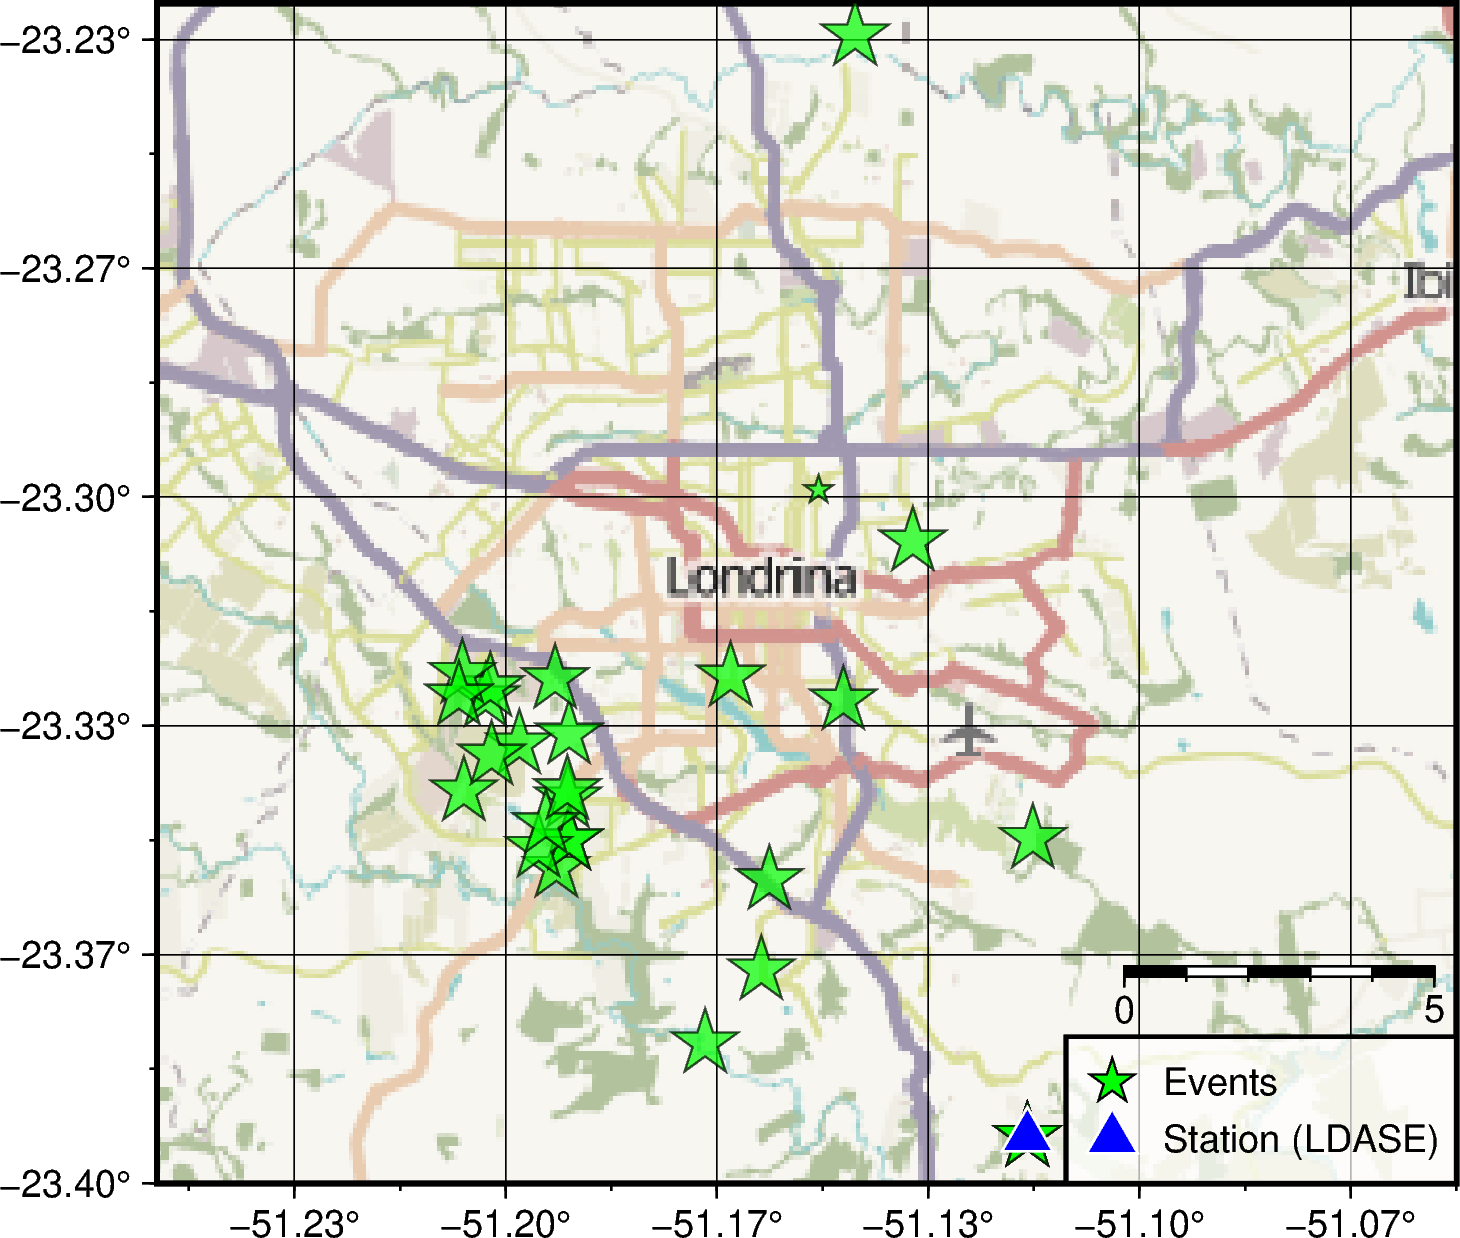

In [20]:
# BEM CORRELACIONADO
ids = """
usp2016atho usp2016atoc usp2016avbr usp2016bhqu usp2018blwx usp2018boet usp2018bojv usp2018cdft usp2018cxej usp2018dbep usp2018dbml usp2024qgjq usp2025zgiy usp2025zgnd usp2025zgng usp2026abut usp2026aekk usp2026agbq usp2026ahfx usp2026ahov usp2026alkz usp2026anvt usp2026aqoy usp2026arqi usp2026bfhg usp2026bitf usp2026bkpk usp2026cnlf
""".split()

ep = Catalog()
for event_id in ids:
    ep += cl.get_events(eventid=event_id)

diff = []
for evid in ep:
    event_id = str(evid.resource_id)
    P = get_time(event_id[-11:], 'P')
    S = get_time(event_id[-11:], 'S')
    diff.append(S - P)
# Normaliza S-P entre 0 e 1
diff = np.array(diff)
diff = [(item - diff.min()) / (diff.max() - diff.min()) for item in diff]

# Define o tamanho das estrelas mínimo = 0.15 cm máximo = 0.8 cm
star_size = [0.25 + 0.35 * np.sqrt(x) for x in diff]
coords = ep2c(ep)


fig = pygmt.Figure()

pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig.tilemap(
    region=[minlon,maxlon,minlat,maxlat],
    projection="M11c",
    zoom=11,
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=Axis(annot=True, tick=True, grid=True),
)

# fig.plot(ep2c(ep),
#          style = "a0.2",
#          pen  = '.4p,black',
#          fill  = "GREEN",
#          transparency = 30, label = 'Events')
fig.plot(x=coords["x"],
         y=coords["y"],
         style="a",
         size=star_size,
         pen=".4p,black",
         fill="GREEN",
         transparency=30,
        )
fig.plot(
    x=[np.nan],
    y=[np.nan],
    style="a0.4c",
    pen=".4p,black",
    fill="GREEN",
    label="Events",
    )

fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (LDASE)")

fig.legend(position="BR",
           line_spacing = 1.5,
           box = Box(pen="1p,black", fill="white@30"))

fig.scalebar(
    length="5k",
    position=("9.5c", "1.75c"),
    fancy=True,
    height=None,
    box=False
)

print(f"Num events: {len(ep)}\n")
fig.show()

Num events: 19



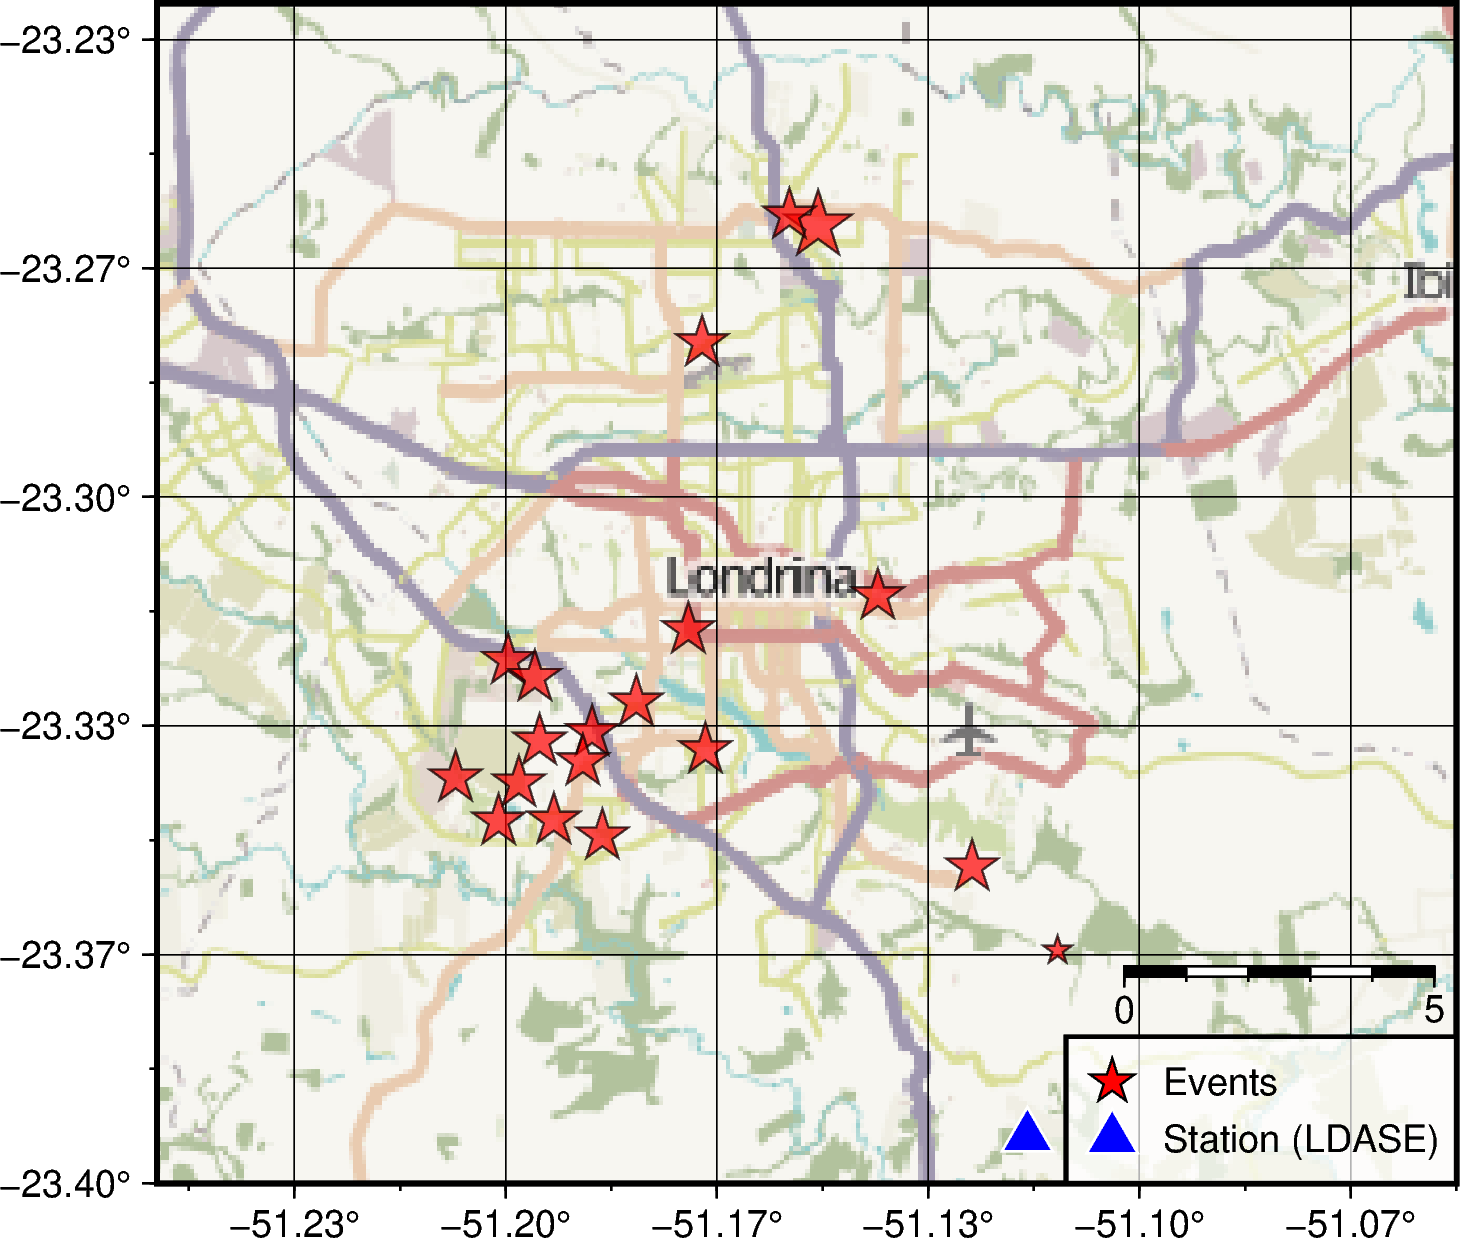

In [21]:
# MAL CORRELACIONADO
ids = """
usp2016asmh usp2016bhsg usp2016bhtr usp2016blue usp2016cink usp2018tliv usp2019dmvk usp2019hlbl usp2020nkhq usp2025zgau usp2025zgjg usp2025zgno usp2025zgxm usp2025zmtj usp2025znlc usp2025zohl usp2026afxw usp2026afyv usp2026aqny
""".split()

ep = Catalog()
for event_id in ids:
    ep += cl.get_events(eventid=event_id)

diff = []
for evid in ep:
    event_id = str(evid.resource_id)
    P = get_time(event_id[-11:], 'P')
    S = get_time(event_id[-11:], 'S')
    diff.append(S - P)
# Normaliza S-P entre 0 e 1
diff = np.array(diff)
diff = [(item - diff.min()) / (diff.max() - diff.min()) for item in diff]

# Define o tamanho das estrelas mínimo = 0.15 cm máximo = 0.8 cm
star_size = [0.25 + 0.35 * np.sqrt(x) for x in diff]
coords = ep2c(ep)

fig = pygmt.Figure()

pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")

fig.tilemap(
    region=[minlon,maxlon,minlat,maxlat],
    projection="M11c",
    zoom=11,
    source="https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png",
    frame=Axis(annot=True, tick=True, grid=True),
)

# fig.plot(ep2c(ep),
#          style = "a0.2",
#          pen  = '.4p,black',
#          fill  = "RED",
#          transparency = 30, label = 'Events')
fig.plot(x=coords["x"],
         y=coords["y"],
         style="a",
         size=star_size,
         pen=".4p,black",
         fill="RED",
         transparency=30,
        )

fig.plot(
    x=[np.nan],
    y=[np.nan],
    style="a0.4c",
    pen=".4p,black",
    fill="RED",
    label="Events",
    )

fig.plot(mda2c(rsbr),  style="t0.5", pen="0.5p,white", fill="blue", label = "Station (LDASE)")

fig.legend(position="BR",
           line_spacing = 1.5,
           box = Box(pen="1p,black", fill="white@30"))

fig.scalebar(
    length="5k",
    position=("9.5c", "1.75c"),
    fancy=True,
    height=None,
    box=False
)

print(f"Num events: {len(ep)}\n")
fig.show()